# 03 — Eksperimen dan Pemilihan Kandidat Model

**Project:** NutriSmart AI  
**Kasus:** Klasifikasi biner risiko pola hidup terhadap obesitas

## Tujuan

1. Membaca data hasil notebook 02.
2. Membandingkan Logistic Regression, Random Forest, dan Gradient Boosting.
3. Menggunakan stratified 5-fold cross-validation pada data training.
4. Membandingkan accuracy, precision, recall, F1-score, dan ROC-AUC.
5. Memilih kandidat berdasarkan F1-score.
6. Melakukan hyperparameter tuning.
7. Menyimpan kandidat model untuk notebook 04.

> Data testing belum digunakan untuk evaluasi final pada notebook ini.


## Konsep utama

- **Training data:** dipakai untuk belajar, cross-validation, dan tuning.
- **Testing data:** disimpan untuk evaluasi akhir pada notebook 04.
- **F1-score:** metrik utama karena menyeimbangkan precision dan recall.
- **Pipeline:** menyatukan preprocessing dan model agar proses konsisten dan mengurangi risiko leakage.


In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
N_SPLITS = 5
N_JOBS = 1  # Aman untuk pemula/Windows. Ubah ke -1 jika komputer stabil dan ingin memakai semua core.
print("Library berhasil dimuat.")


Library berhasil dimuat.


## 1. Membaca data hasil preprocessing

Notebook membutuhkan:

- `data/processed/train_lifestyle_raw.csv`
- `data/processed/test_lifestyle_raw.csv`
- `artifacts/preprocessing_metadata.json`


In [2]:
TRAIN_FILENAME = "train_lifestyle_raw.csv"
TEST_FILENAME = "test_lifestyle_raw.csv"

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path for path in candidate_roots
        if (
            (path / "data" / "processed" / TRAIN_FILENAME).exists()
            and (path / "data" / "processed" / TEST_FILENAME).exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "File hasil notebook 02 tidak ditemukan. Jalankan notebook 02 terlebih dahulu."
    )

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DATA_DIR / TRAIN_FILENAME
TEST_PATH = PROCESSED_DATA_DIR / TEST_FILENAME
METADATA_PATH = ARTIFACTS_DIR / "preprocessing_metadata.json"

train_data = pd.read_csv(TRAIN_PATH, index_col="source_index")
test_data = pd.read_csv(TEST_PATH, index_col="source_index")

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

print(f"Project root : {PROJECT_ROOT}")
print(f"Train shape  : {train_data.shape}")
print(f"Test shape   : {test_data.shape}")
display(train_data.head())


Project root : C:\Projects\nutrismart-ai
Train shape  : (1669, 11)
Test shape   : (418, 11)


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS,Obesity_Binary
source_index,,,,,,,,,,,
2083,3.0000,3.0000,2.0051,1.3414,0.5993,yes,Sometimes,no,Sometimes,Public_Transportation,1
1230,2.0000,3.0000,1.6081,0.4781,0.0000,yes,Sometimes,no,no,Public_Transportation,1
675,2.0513,2.6459,2.3575,0.2913,0.8979,yes,Sometimes,no,Sometimes,Public_Transportation,0
193,2.0000,1.0000,1.0000,0.0000,2.0000,yes,Frequently,no,no,Public_Transportation,0
1217,2.0000,1.1056,1.3728,1.6294,0.0000,yes,Sometimes,no,Sometimes,Automobile,1


## 2. Memisahkan fitur dan target

Target:

```text
0 = Non-Obesity
1 = Obesity
```

Data testing hanya diperiksa strukturnya. Data tersebut belum dipakai untuk pemilihan model.


In [3]:
TARGET_COLUMN = "Obesity_Binary"

X_train = train_data.drop(columns=[TARGET_COLUMN]).copy()
y_train = train_data[TARGET_COLUMN].copy()
X_test = test_data.drop(columns=[TARGET_COLUMN]).copy()
y_test = test_data[TARGET_COLUMN].copy()

def class_distribution(series):
    result = series.value_counts().sort_index().to_frame("count")
    result["percentage"] = (result["count"] / len(series) * 100).round(2)
    result.index = result.index.map({0: "Non-Obesity", 1: "Obesity"})
    return result

print("Distribusi training:")
display(class_distribution(y_train))
print("Distribusi testing, hanya pemeriksaan struktur:")
display(class_distribution(y_test))


Distribusi training:


,count,percentage
Obesity_Binary,,
Non-Obesity,892,53.4500
Obesity,777,46.5500


Distribusi testing, hanya pemeriksaan struktur:


,count,percentage
Obesity_Binary,,
Non-Obesity,223,53.3500
Obesity,195,46.6500


## 3. Memastikan fitur konsisten dan bebas leakage

Daftar fitur diambil dari metadata notebook 02. Tinggi, berat, BMI, target asli, dan target biner tidak boleh masuk ke input model.


In [4]:
NUMERIC_FEATURES = metadata["numeric_features"]
CATEGORICAL_FEATURES = metadata["categorical_features"]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

forbidden_features = {
    "Height", "Weight", "BMI", "BMI_EDA", "NObeyesdad", "Obesity_Binary"
}

assert list(X_train.columns) == MODEL_FEATURES
assert list(X_test.columns) == MODEL_FEATURES
assert not forbidden_features.intersection(MODEL_FEATURES)

print("Fitur numerik     :", NUMERIC_FEATURES)
print("Fitur kategorikal :", CATEGORICAL_FEATURES)
print("Pemeriksaan anti-leakage berhasil.")


Fitur numerik     : ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Fitur kategorikal : ['FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS']
Pemeriksaan anti-leakage berhasil.


## 4. Membuat preprocessing

Numerik: median imputation dan standard scaling.  
Kategorikal: most-frequent imputation dan one-hot encoding.


In [5]:
def build_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

print(build_preprocessor())


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS'])],
                  verbose_feature_names_out=False)


## 5. Membuat tiga model baseline

- Logistic Regression sebagai baseline linear.
- Random Forest sebagai ensemble decision tree.
- Gradient Boosting sebagai ensemble bertahap.


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model),
        ]
    )
    for name, model in models.items()
}

print("Model yang dibandingkan:")
for name in pipelines:
    print("-", name)


Model yang dibandingkan:
- Logistic Regression
- Random Forest
- Gradient Boosting


## 6. Menentukan cross-validation dan metrik

Digunakan Stratified 5-Fold Cross-Validation. Kelas positif adalah `1 = Obesity`.


In [7]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

print(cv)
print(scoring)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
{'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}


## 7. Menjalankan eksperimen baseline

Setiap model memakai data training, fold, dan metrik yang sama. Hasil berupa rata-rata dan standar deviasi lima fold.


In [8]:
experiment_rows = []

for model_name, pipeline in pipelines.items():
    print(f"Menjalankan: {model_name}")
    start_time = time.time()

    result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=N_JOBS,
    )

    experiment_rows.append(
        {
            "model": model_name,
            "cv_accuracy_mean": result["test_accuracy"].mean(),
            "cv_accuracy_std": result["test_accuracy"].std(),
            "cv_precision_mean": result["test_precision"].mean(),
            "cv_precision_std": result["test_precision"].std(),
            "cv_recall_mean": result["test_recall"].mean(),
            "cv_recall_std": result["test_recall"].std(),
            "cv_f1_mean": result["test_f1"].mean(),
            "cv_f1_std": result["test_f1"].std(),
            "cv_roc_auc_mean": result["test_roc_auc"].mean(),
            "cv_roc_auc_std": result["test_roc_auc"].std(),
            "train_f1_mean": result["train_f1"].mean(),
            "f1_generalization_gap": (
                result["train_f1"].mean() - result["test_f1"].mean()
            ),
            "elapsed_seconds": time.time() - start_time,
        }
    )

baseline_results = (
    pd.DataFrame(experiment_rows)
    .sort_values(
        ["cv_f1_mean", "cv_roc_auc_mean", "cv_recall_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(baseline_results)


Menjalankan: Logistic Regression
Menjalankan: Random Forest
Menjalankan: Gradient Boosting


,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,train_f1_mean,f1_generalization_gap,elapsed_seconds
0,Random Forest,0.8939,0.0073,0.8974,0.0181,0.8726,0.0185,0.8845,0.0079,0.9538,0.0044,0.9971,0.1126,4.1845
1,Gradient Boosting,0.8364,0.0081,0.8026,0.0113,0.8611,0.0342,0.8303,0.0122,0.9208,0.0104,0.8950,0.0647,1.7736
2,Logistic Regression,0.7256,0.0058,0.6733,0.0121,0.7993,0.0253,0.7305,0.0057,0.8126,0.0107,0.7371,0.0066,0.7338


## 8. Visualisasi hasil baseline

Metrik yang lebih tinggi umumnya lebih baik. Generalization gap yang besar dapat menandakan overfitting.


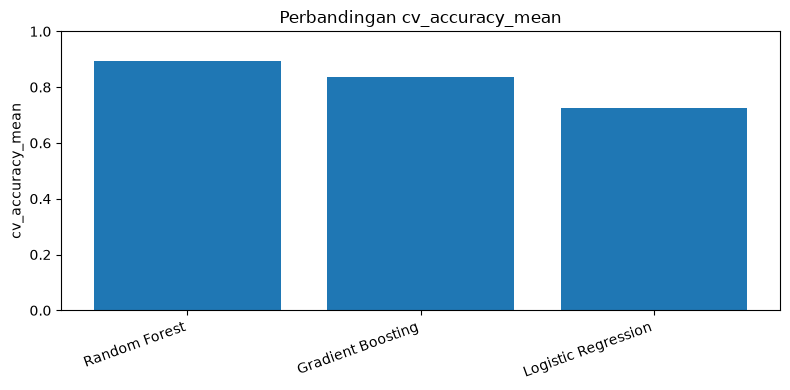

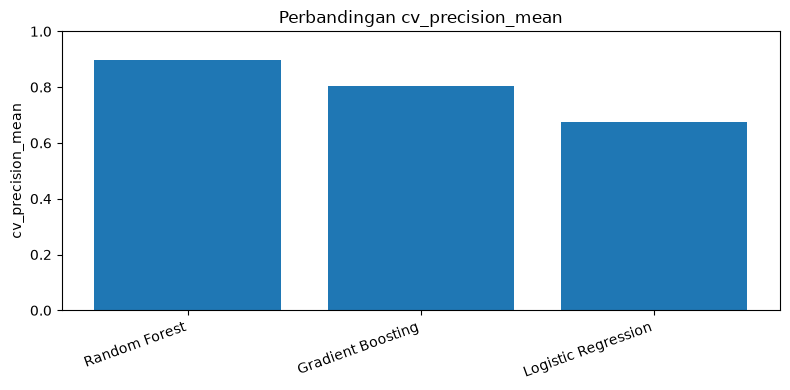

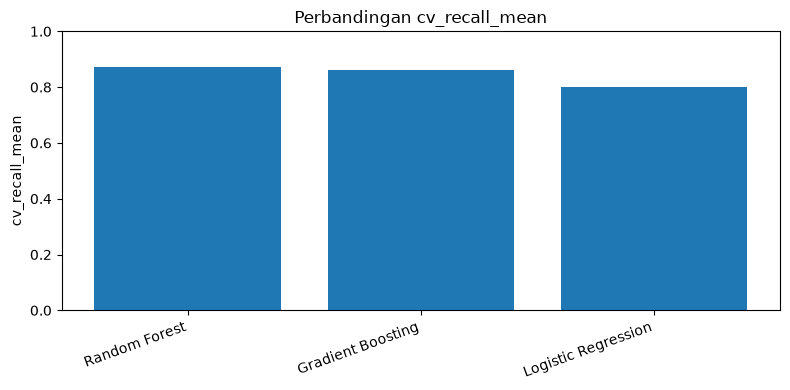

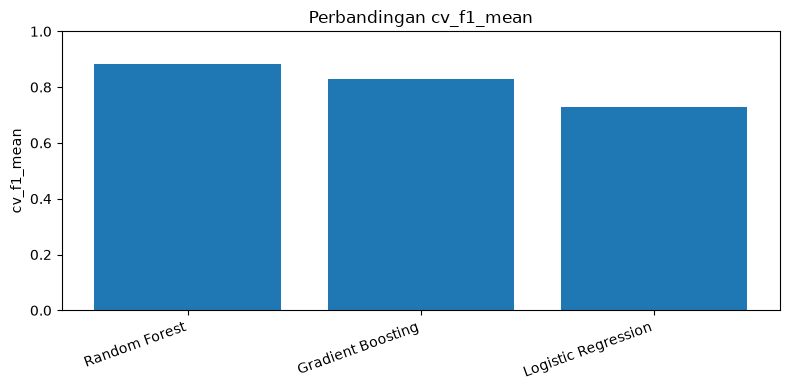

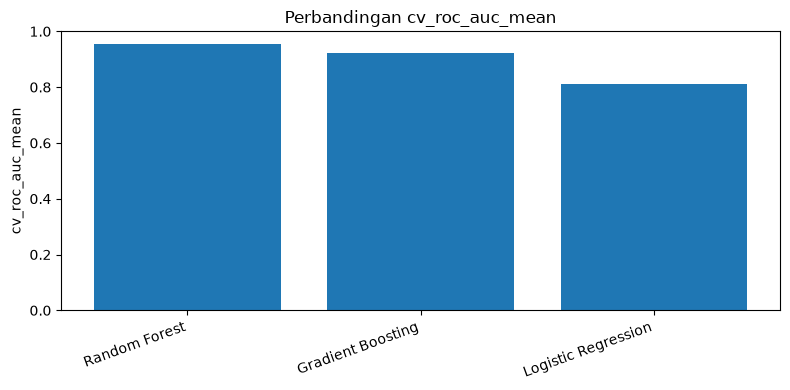

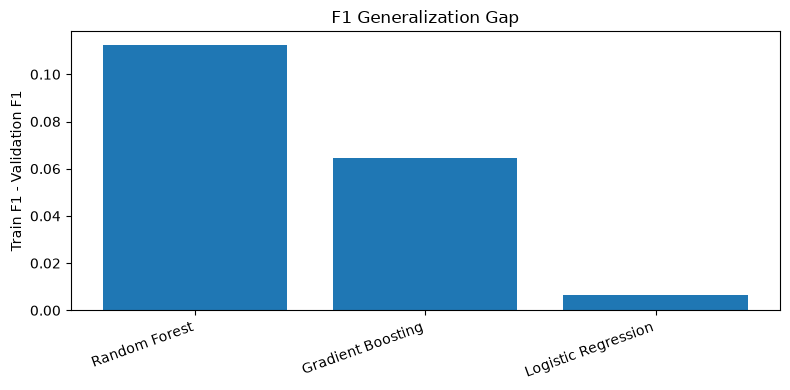

In [9]:
for metric in [
    "cv_accuracy_mean",
    "cv_precision_mean",
    "cv_recall_mean",
    "cv_f1_mean",
    "cv_roc_auc_mean",
]:
    plt.figure(figsize=(8, 4))
    plt.bar(baseline_results["model"], baseline_results[metric])
    plt.title(f"Perbandingan {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
plt.bar(baseline_results["model"], baseline_results["f1_generalization_gap"])
plt.title("F1 Generalization Gap")
plt.ylabel("Train F1 - Validation F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 9. Memilih kandidat baseline

Urutan utama adalah F1-score, lalu ROC-AUC, recall, kestabilan, dan generalization gap.


In [10]:
best_baseline_row = baseline_results.iloc[0]
best_baseline_name = best_baseline_row["model"]

print(f"Kandidat baseline : {best_baseline_name}")
print(f"CV F1             : {best_baseline_row['cv_f1_mean']:.4f}")
print(f"CV Recall         : {best_baseline_row['cv_recall_mean']:.4f}")
print(f"CV ROC-AUC        : {best_baseline_row['cv_roc_auc_mean']:.4f}")
print(f"F1 gap            : {best_baseline_row['f1_generalization_gap']:.4f}")


Kandidat baseline : Random Forest
CV F1             : 0.8845
CV Recall         : 0.8726
CV ROC-AUC        : 0.9538
F1 gap            : 0.1126


## 10. Menentukan hyperparameter grid

Grid dibuat cukup kecil agar realistis dijalankan pada laptop.


In [11]:
parameter_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt"],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__subsample": [0.8, 1.0],
    },
}

candidate_pipeline = pipelines[best_baseline_name]
candidate_grid = parameter_grids[best_baseline_name]
combination_count = int(np.prod([len(values) for values in candidate_grid.values()]))

print(f"Model dituning      : {best_baseline_name}")
print(f"Jumlah kombinasi    : {combination_count}")
print(f"Perkiraan total fit : {combination_count * N_SPLITS}")
display(pd.Series(candidate_grid, name="candidate_values").to_frame())


Model dituning      : Random Forest
Jumlah kombinasi    : 12
Perkiraan total fit : 60


,candidate_values
model__n_estimators,"[200, 400]"
model__max_depth,"[None, 10, 20]"
model__min_samples_leaf,"[1, 2]"
model__max_features,[sqrt]


## 11. Menjalankan GridSearchCV

Grid search hanya memakai data training. Kombinasi terbaik dipilih berdasarkan F1-score.


In [16]:
grid_search = GridSearchCV(
    estimator=candidate_pipeline,
    param_grid=candidate_grid,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=N_JOBS,
    return_train_score=True,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
tuning_elapsed_seconds = time.time() - start_time

print("Grid search selesai.")
print(f"Waktu total : {tuning_elapsed_seconds:.2f} detik")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")
print(f"Best params : {grid_search.best_params_}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid search selesai.
Waktu total : 57.55 detik
Best CV F1  : 0.8842
Best params : {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


## 12. Memeriksa hasil tuning

Train F1 dan validation F1 dibandingkan untuk melihat indikasi overfitting.


In [17]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results_summary = grid_results[
    [
        "rank_test_f1",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_roc_auc",
        "mean_test_accuracy",
        "mean_train_f1",
        "std_train_f1",
        "mean_fit_time",
        "params",
    ]
].sort_values("rank_test_f1").reset_index(drop=True)

grid_results_summary["f1_generalization_gap"] = (
    grid_results_summary["mean_train_f1"] - grid_results_summary["mean_test_f1"]
)

display(grid_results_summary.head(15))


,rank_test_f1,mean_test_f1,std_test_f1,mean_test_recall,mean_test_precision,mean_test_roc_auc,mean_test_accuracy,mean_train_f1,std_train_f1,mean_fit_time,params,f1_generalization_gap
0,1,0.8842,0.0053,0.8752,0.8943,0.9540,0.8933,0.9971,0.0004,1.0308,"{'model__max_depth': None, 'model__max_feature...",0.1129
1,2,0.8841,0.0063,0.8829,0.8865,0.9522,0.8921,0.9630,0.0023,0.4575,"{'model__max_depth': 20, 'model__max_features'...",0.0789
2,3,0.8837,0.0089,0.8714,0.8976,0.9538,0.8934,0.9971,0.0004,0.4824,"{'model__max_depth': 20, 'model__max_features'...",0.1134
3,4,0.8833,0.0059,0.8816,0.8862,0.9521,0.8915,0.9630,0.0020,0.4902,"{'model__max_depth': None, 'model__max_feature...",0.0797
4,5,0.8831,0.0075,0.8752,0.8924,0.9540,0.8922,0.9971,0.0004,0.9581,"{'model__max_depth': 20, 'model__max_features'...",0.1140
5,6,0.8830,0.0055,0.8791,0.8884,0.9522,0.8915,0.9634,0.0014,0.8877,"{'model__max_depth': 20, 'model__max_features'...",0.0804
6,6,0.8830,0.0055,0.8791,0.8884,0.9522,0.8915,0.9631,0.0015,0.9145,"{'model__max_depth': None, 'model__max_feature...",0.0801
7,8,0.8828,0.0049,0.8726,0.8943,0.9532,0.8922,0.9971,0.0004,0.4986,"{'model__max_depth': None, 'model__max_feature...",0.1143
8,9,0.8719,0.0060,0.8932,0.8526,0.9469,0.8778,0.9472,0.0040,0.4544,"{'model__max_depth': 10, 'model__max_features'...",0.0753
9,10,0.8716,0.0073,0.8907,0.8547,0.9464,0.8778,0.9478,0.0051,0.8696,"{'model__max_depth': 10, 'model__max_features'...",0.0762


In [21]:
best_grid_row = grid_results.loc[grid_search.best_index_]

comparison = pd.DataFrame(
    [
        {
            "stage": "Baseline",
            "accuracy": best_baseline_row["cv_accuracy_mean"],
            "precision": best_baseline_row["cv_precision_mean"],
            "recall": best_baseline_row["cv_recall_mean"],
            "f1": best_baseline_row["cv_f1_mean"],
            "roc_auc": best_baseline_row["cv_roc_auc_mean"],
            "f1_gap": best_baseline_row["f1_generalization_gap"],
        },
        {
            "stage": "Tuned",
            "accuracy": best_grid_row["mean_test_accuracy"],
            "precision": best_grid_row["mean_test_precision"],
            "recall": best_grid_row["mean_test_recall"],
            "f1": best_grid_row["mean_test_f1"],
            "roc_auc": best_grid_row["mean_test_roc_auc"],
            "f1_gap": best_grid_row["mean_train_f1"] - best_grid_row["mean_test_f1"],
        },
    ]
)

display(comparison)


,stage,accuracy,precision,recall,f1,roc_auc,f1_gap
0,Baseline,0.8939,0.8974,0.8726,0.8845,0.9538,0.1126
1,Tuned,0.8933,0.8943,0.8752,0.8842,0.9540,0.1129


## 13. Sanity check kandidat

Sanity check hanya menggunakan beberapa baris training dan bukan evaluasi performa.


In [19]:
candidate_model_pipeline = grid_search.best_estimator_

sample = X_train.head(5)
sanity_result = sample.copy()
sanity_result["actual_target"] = y_train.loc[sample.index]
sanity_result["predicted_target"] = candidate_model_pipeline.predict(sample)
sanity_result["obesity_probability"] = candidate_model_pipeline.predict_proba(sample)[:, 1]

display(sanity_result)


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS,actual_target,predicted_target,obesity_probability
source_index,,,,,,,,,,,,,
2083,3.0000,3.0000,2.0051,1.3414,0.5993,yes,Sometimes,no,Sometimes,Public_Transportation,1,1,0.9650
1230,2.0000,3.0000,1.6081,0.4781,0.0000,yes,Sometimes,no,no,Public_Transportation,1,1,0.9500
675,2.0513,2.6459,2.3575,0.2913,0.8979,yes,Sometimes,no,Sometimes,Public_Transportation,0,0,0.1625
193,2.0000,1.0000,1.0000,0.0000,2.0000,yes,Frequently,no,no,Public_Transportation,0,0,0.0625
1217,2.0000,1.1056,1.3728,1.6294,0.0000,yes,Sometimes,no,Sometimes,Automobile,1,1,0.9100


## 14. Menyimpan hasil eksperimen

File keluaran:

- `baseline_model_results.csv`
- `grid_search_results.csv`
- `model_experiment_summary.json`
- `candidate_model_pipeline.joblib`

Pipeline kandidat belum menjadi model deployment final.


In [20]:
BASELINE_RESULTS_PATH = ARTIFACTS_DIR / "baseline_model_results.csv"
GRID_RESULTS_PATH = ARTIFACTS_DIR / "grid_search_results.csv"
SUMMARY_PATH = ARTIFACTS_DIR / "model_experiment_summary.json"
CANDIDATE_PATH = ARTIFACTS_DIR / "candidate_model_pipeline.joblib"

baseline_results.to_csv(BASELINE_RESULTS_PATH, index=False)
grid_results_summary.to_csv(GRID_RESULTS_PATH, index=False)
joblib.dump(candidate_model_pipeline, CANDIDATE_PATH)

summary = {
    "project": "NutriSmart AI",
    "selection_metric": "f1",
    "positive_class": {"value": 1, "label": "Obesity"},
    "cross_validation": {
        "method": "StratifiedKFold",
        "n_splits": N_SPLITS,
        "shuffle": True,
        "random_state": RANDOM_STATE,
    },
    "training_rows": int(len(X_train)),
    "testing_rows_reserved": int(len(X_test)),
    "features": MODEL_FEATURES,
    "models_compared": list(models.keys()),
    "best_baseline_model": best_baseline_name,
    "best_baseline_cv_f1": float(best_baseline_row["cv_f1_mean"]),
    "best_parameters": grid_search.best_params_,
    "tuned_cv_accuracy": float(best_grid_row["mean_test_accuracy"]),
    "tuned_cv_precision": float(best_grid_row["mean_test_precision"]),
    "tuned_cv_recall": float(best_grid_row["mean_test_recall"]),
    "tuned_cv_f1": float(best_grid_row["mean_test_f1"]),
    "tuned_cv_roc_auc": float(best_grid_row["mean_test_roc_auc"]),
    "tuned_f1_generalization_gap": float(
        best_grid_row["mean_train_f1"] - best_grid_row["mean_test_f1"]
    ),
    "test_data_used_for_final_evaluation": False,
    "candidate_model_file": CANDIDATE_PATH.name,
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2, ensure_ascii=False)

saved_files = []
for path in [BASELINE_RESULTS_PATH, GRID_RESULTS_PATH, SUMMARY_PATH, CANDIDATE_PATH]:
    saved_files.append(
        {
            "file": path.name,
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else None,
        }
    )

display(pd.DataFrame(saved_files))


,file,exists,size_bytes
0,baseline_model_results.csv,True,1029
1,grid_search_results.csv,True,3964
2,model_experiment_summary.json,True,1207
3,candidate_model_pipeline.joblib,True,16680619


## 15. Kesimpulan dan langkah berikutnya

Setelah notebook ini selesai:

1. Tiga model telah dibandingkan.
2. Cross-validation hanya memakai data training.
3. Kandidat dipilih berdasarkan F1-score.
4. Kandidat terbaik telah dituning.
5. Pipeline kandidat telah disimpan.
6. Data testing belum dipakai untuk evaluasi final.

Pada notebook 04 kita akan menghitung confusion matrix, classification report, metrik testing, ROC curve, precision-recall curve, threshold analysis, feature importance, dan mengekspor model final.

## Checklist

- [ ] Semua cell berjalan tanpa error.
- [ ] Tiga model berhasil dibandingkan.
- [ ] Data testing belum dipakai untuk pemilihan model.
- [ ] Kandidat terbaik berhasil dituning.
- [ ] Generalization gap diperiksa.
- [ ] Empat artifact berhasil tersimpan.
- [ ] Notebook disimpan dan di-commit.
